# 08 Discrete Probability Distributions

Chapter 07 introduced random variables and probability distributions.

Now we study specific mathematical models for **discrete random variables**.

This chapter focuses on two fundamental distributions:

- **Bernoulli Distribution**
- **Binomial Distribution**

These distributions appear whenever we model repeated success/failure experiments.

## Learning Objectives

After completing this chapter, you will be able to:

- explain a Bernoulli trial;
- identify the success probability $p$ and failure probability $1-p$;
- explain when a binomial model is appropriate;
- calculate binomial probabilities;
- distinguish `PMF`, `CDF`, and survival probabilities;
- calculate the mean and variance of a binomial distribution;
- visualize how $n$ and $p$ affect the distribution;
- compare theoretical probabilities with simulated results.

## 1. Bernoulli Distribution

A **Bernoulli trial** has only two possible outcomes.

We usually encode them as:

$$
X =
\begin{cases}
1 & \text{Success}\\
0 & \text{Failure}
\end{cases}
$$

If the probability of success is $p$, then:

$$
P(X=1)=p
$$

and:

$$
P(X=0)=1-p
$$

Examples include:

- delivery is on time / late;
- product passes / fails inspection;
- customer purchases / does not purchase.

## 2. A Simple Bernoulli Example

Suppose the probability that one fictional delivery arrives on time is:

$$
p=0.80
$$

Then:

$$
P(X=1)=0.80
$$

and:

$$
P(X=0)=0.20
$$

The value 0.80 is an **assumed model parameter for this educational example**. It is not estimated from real delivery data.

In [1]:
p = 0.80

print(f"P(Success) = {p:.2f}")
print(f"P(Failure) = {1 - p:.2f}")

P(Success) = 0.80
P(Failure) = 0.20


## 3. From Bernoulli to Binomial

Now suppose we repeat the same type of Bernoulli trial several times.

Define:

$$
X=\text{number of successes in }n\text{ trials}
$$

If the usual binomial assumptions hold, then:

$$
X \sim \mathrm{Binomial}(n,p)
$$

A binomial model requires:

1. a fixed number of trials $n$;
2. two outcomes per trial: success or failure;
3. the same success probability $p$ for each trial;
4. independence between trials.

## 4. Binomial Probability Formula

The probability of exactly $k$ successes in $n$ trials is:

$$
P(X=k)
=
\binom{n}{k}
p^k(1-p)^{n-k}
$$

where:

$$
\binom{n}{k}
=
\frac{n!}{k!(n-k)!}
$$

The combination term counts how many different arrangements can produce exactly $k$ successes.

## Sample Dataset

The CSV stores several **educational probability-model scenarios**.

It is not a collection of individual observations.

| Column | Meaning |
|---|---|
| `distribution` | Probability model |
| `scenario` | Fictional situation |
| `n_trials` | Number of trials |
| `success_probability` | Assumed probability of success $p$ |

As in Chapter 07, the probabilities are deliberately specified for learning purposes.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import bernoulli, binom

In [3]:
current_dir = Path.cwd().resolve()
project_root = next(
    (p for p in [current_dir, *current_dir.parents] if (p / "data").is_dir()),
    None,
)

if project_root is None:
    raise FileNotFoundError("Could not find the project root containing data/.")

data_path = project_root / "data" / "08_discrete_probability_distributions.csv"
df = pd.read_csv(data_path)
df

,distribution,scenario,n_trials,success_probability
0,Bernoulli,Delivery arrives on time,1,0.80
1,Binomial,On-time deliveries among 10 deliveries,10,0.80
2,Binomial,Successful inspections among 8 inspections,8,0.70
3,Binomial,Customers who purchase among 12 visitors,12,0.25


## 5. Bernoulli Distribution with SciPy

In [4]:
p = 0.80

print(f"P(X = 0) = {bernoulli.pmf(0, p):.3f}")
print(f"P(X = 1) = {bernoulli.pmf(1, p):.3f}")

P(X = 0) = 0.200
P(X = 1) = 0.800


## 6. Binomial Example

Suppose we observe 10 fictional deliveries.

Assume each delivery has an 80% probability of arriving on time.

Define:

$$
X=\text{number of on-time deliveries among 10 deliveries}
$$

Then:

$$
X\sim\mathrm{Binomial}(10,0.8)
$$

What is the probability that **exactly 8** deliveries arrive on time?

In [5]:
n = 10
p = 0.80
k = 8

probability_exactly_8 = binom.pmf(k, n, p)

print(f"P(X = 8) = {probability_exactly_8:.4f}")

P(X = 8) = 0.3020


### PMF

For a discrete random variable, the **Probability Mass Function (PMF)** gives:

$$
P(X=k)
$$

In SciPy:

```python
binom.pmf(k, n, p)
```

Use the PMF when asking for the probability of **exactly** a particular value.

## 7. Probability of At Most k Successes

The probability of **at most 8 successes** is:

$$
P(X\leq8)
$$

For this we use the **Cumulative Distribution Function (CDF)**.

In [6]:
probability_at_most_8 = binom.cdf(8, n, p)

print(f"P(X <= 8) = {probability_at_most_8:.4f}")

P(X <= 8) = 0.6242


### CDF

The CDF gives:

$$
F(k)=P(X\leq k)
$$

In SciPy:

```python
binom.cdf(k, n, p)
```

## 8. Probability of More Than k Successes

For:

$$
P(X>8)
$$

we could calculate:

$$
1-P(X\leq8)
$$

SciPy also provides the **survival function** (`sf`).

In [7]:
probability_more_than_8 = binom.sf(8, n, p)

print(f"P(X > 8) = {probability_more_than_8:.4f}")

P(X > 8) = 0.3758


## 9. The Entire Binomial Distribution

For $n=10$, the possible values are:

$$
X=0,1,2,\ldots,10
$$

We can calculate $P(X=k)$ for every possible value.

In [8]:
x_values = np.arange(0, n + 1)
probabilities = binom.pmf(x_values, n, p)

distribution = pd.DataFrame({
    "x": x_values,
    "probability": probabilities,
})

distribution

,x,probability
0,0,1.024000e-07
1,1,4.096000e-06
2,2,7.372800e-05
3,3,7.864320e-04
4,4,5.505024e-03
5,5,2.642412e-02
6,6,8.808038e-02
7,7,2.013266e-01
8,8,3.019899e-01
9,9,2.684355e-01


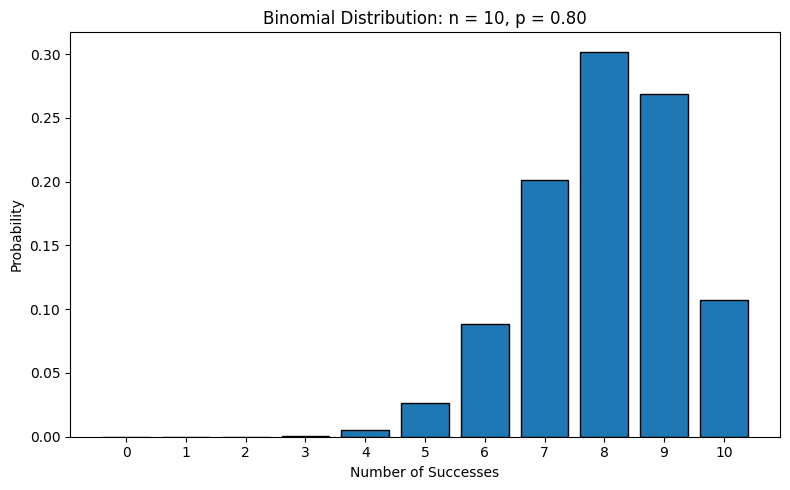

In [9]:
plt.figure(figsize=(8, 5))

plt.bar(distribution["x"], distribution["probability"], edgecolor="black")

plt.title("Binomial Distribution: n = 10, p = 0.80")
plt.xlabel("Number of Successes")
plt.ylabel("Probability")
plt.xticks(x_values)
plt.tight_layout()
plt.show()

## 10. Mean and Variance of the Binomial Distribution

For:

$$
X\sim\mathrm{Binomial}(n,p)
$$

the expected value is:

$$
E[X]=np
$$

and the variance is:

$$
\mathrm{Var}(X)=np(1-p)
$$

The standard deviation is:

$$
\sigma=\sqrt{np(1-p)}
$$

In [10]:
mean = n * p
variance = n * p * (1 - p)
std = np.sqrt(variance)

print(f"E[X]   = {mean:.3f}")
print(f"Var(X) = {variance:.3f}")
print(f"SD(X)  = {std:.3f}")

E[X]   = 8.000
Var(X) = 1.600
SD(X)  = 1.265


For $n=10$ and $p=0.80$:

$$
E[X]=10(0.80)=8
$$

This means that over many repeated sets of 10 deliveries, the average number of on-time deliveries would approach 8.

It does **not** mean that every set of 10 deliveries will contain exactly 8 successes.

## 11. How Does p Change the Shape?

Keep $n=10$ fixed and compare several values of $p$.

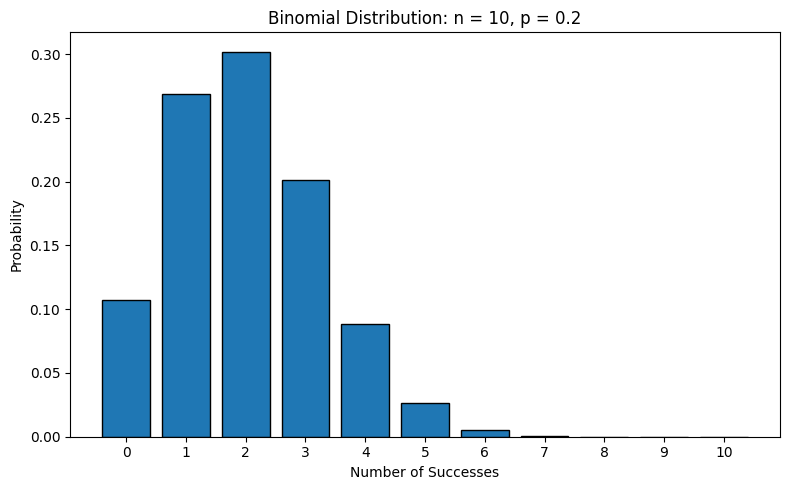

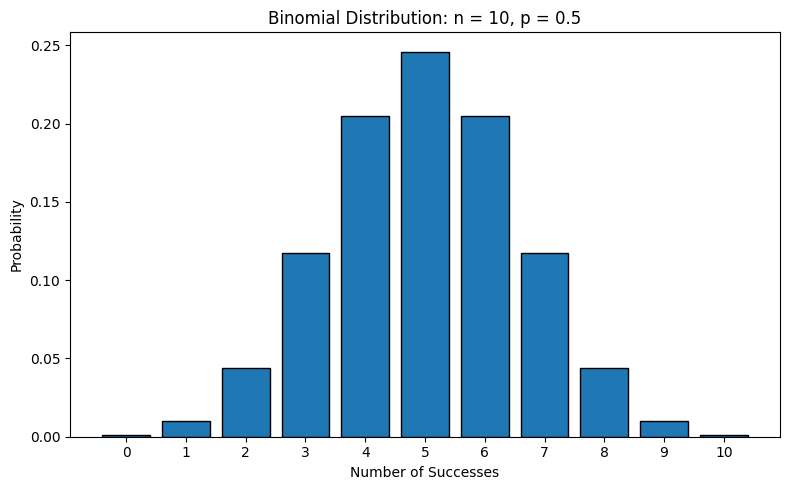

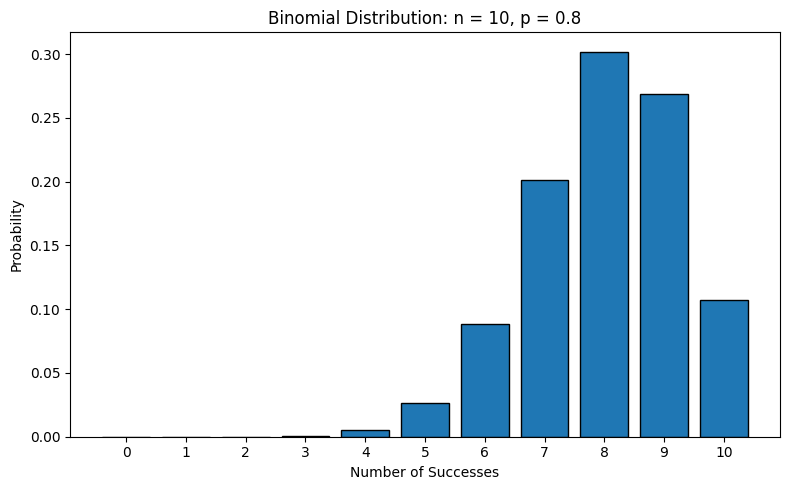

In [11]:
n = 10
x_values = np.arange(0, n + 1)

for p_value in [0.20, 0.50, 0.80]:
    probabilities = binom.pmf(x_values, n, p_value)

    plt.figure(figsize=(8, 5))
    plt.bar(x_values, probabilities, edgecolor="black")
    plt.title(f"Binomial Distribution: n = {n}, p = {p_value}")
    plt.xlabel("Number of Successes")
    plt.ylabel("Probability")
    plt.xticks(x_values)
    plt.tight_layout()
    plt.show()

### Interpretation

When $p$ is small, the distribution is concentrated near smaller numbers of successes.

When $p=0.5$, the distribution is symmetric.

When $p$ is large, the distribution is concentrated near larger numbers of successes.

## 12. Simulation

We can simulate repeated binomial experiments.

Suppose we repeat the 10-delivery experiment 10,000 times.

In [12]:
rng = np.random.default_rng(seed=42)

simulated_successes = rng.binomial(
    n=10,
    p=0.80,
    size=10_000,
)

print(f"Theoretical mean: {10 * 0.80:.4f}")
print(f"Simulated mean:   {simulated_successes.mean():.4f}")

Theoretical mean: 8.0000
Simulated mean:   8.0092


## 13. Theoretical vs Simulated Distribution

We can compare simulated relative frequencies with the theoretical binomial probabilities.

In [13]:
n = 10
p = 0.80
x_values = np.arange(0, n + 1)

theoretical = binom.pmf(x_values, n, p)

simulated_counts = pd.Series(simulated_successes).value_counts().reindex(
    x_values,
    fill_value=0,
)

simulated_relative_frequency = simulated_counts / len(simulated_successes)

comparison = pd.DataFrame({
    "x": x_values,
    "theoretical_probability": theoretical,
    "simulated_relative_frequency": simulated_relative_frequency.values,
})

comparison.round(4)

,x,theoretical_probability,simulated_relative_frequency
0,0,0.0000,0.0000
1,1,0.0000,0.0000
2,2,0.0001,0.0001
3,3,0.0008,0.0009
4,4,0.0055,0.0058
5,5,0.0264,0.0263
6,6,0.0881,0.0846
7,7,0.2013,0.1988
8,8,0.3020,0.3047
9,9,0.2684,0.2732


The simulated frequencies will not match the theoretical probabilities exactly.

However, with many repetitions they should generally be close.

This connects the probability model from Chapters 07–08 with the experimental-probability idea introduced in Chapter 06.

## 14. When Is a Binomial Model Appropriate?

Consider whether these conditions hold:

- Is the number of trials fixed?
- Does each trial have only two outcomes?
- Is the probability of success constant?
- Can the trials reasonably be treated as independent?

If one or more of these assumptions fail, the binomial distribution may not be an appropriate model.

Choosing a probability distribution is therefore not only a calculation problem. It is also a **modeling decision**.

## Exercises

### Exercise 1
For a Bernoulli trial with $p=0.65$, calculate $P(X=1)$ and $P(X=0)$.

### Exercise 2
Let:

$$
X\sim\mathrm{Binomial}(8,0.70)
$$

Calculate:

1. $P(X=6)$
2. $P(X\leq6)$
3. $P(X>6)$

### Exercise 3
For $X\sim\mathrm{Binomial}(12,0.25)$, calculate the expected value, variance, and standard deviation.

### Exercise 4
Plot the binomial distribution for $n=20$ and $p=0.50$.

### Exercise 5
Simulate 100,000 observations from $\mathrm{Binomial}(10,0.80)$ and compare the simulated mean with $np$.

### Exercise 6
Decide whether a binomial model is appropriate for each situation and explain why:

1. Number of heads in 20 fair coin tosses
2. Temperature measured every hour
3. Number of defective items among 50 independently produced items with a constant defect probability
4. Waiting time until the next customer arrives

## Summary

In this chapter, you learned two fundamental discrete probability distributions.

### Bernoulli Distribution

Models one success/failure trial.

### Binomial Distribution

Models the number of successes in a fixed number of Bernoulli trials.

You also learned how to:

- calculate exact probabilities with the PMF;
- calculate cumulative probabilities with the CDF;
- calculate upper-tail probabilities;
- calculate expected value, variance, and standard deviation;
- visualize the distribution;
- simulate binomial random variables;
- check whether the assumptions of a binomial model are reasonable.

Next:

# 09 Continuous Probability Distributions

We will move from countable outcomes to continuous measurements and introduce distributions such as the **Normal Distribution**.